In [47]:
import numpy as np

import json
from matplotlib import pyplot as plt 
from pathlib import Path

from matplotlib import cm
import pandas as pd

In [17]:
# DATA_DIR = Path("../../tmp/toy-experiments-5k")
# DATA_DIR = Path("../../artifacts/2023-05-s6/dev/toy-experiments")
DATA_DIR = Path("../../artifacts/2023-05-s6/toy-experiments")

# Accuracy and AUROC Analysis Across Noise

In [18]:
def load_meta(
    model,
    seed, 
    eps
):
    
#     "./artifacts/2023-05-s6/dev/toy-experiments/toy-dataset-eps1.0-seed1/meta.json"
    
    filepath = DATA_DIR / f"toy-dataset-eps{eps}-seed{seed}" / model / "meta.json"
    
    with open(filepath) as fh:
        return json.load(fh)
    
load_meta("mlp64", seed=1, eps=0.1)

{'accuracy': 0.8996666669845581,
 'aurocs': {'0vs1': 0.9695214573293924,
  '2vs3': 0.9590767621994019,
  '4vs5': 0.9633384943008423},
 'basis_names': 'pca,prca-recon,prca-abs,prca,random1,random2,random3',
 'epochs': 20,
 'eps': 0.1,
 'mode': 'centered',
 'model': 'mlp64',
 'output_dir': './artifacts/2023-05-s6/toy-experiments',
 'seed': 1}

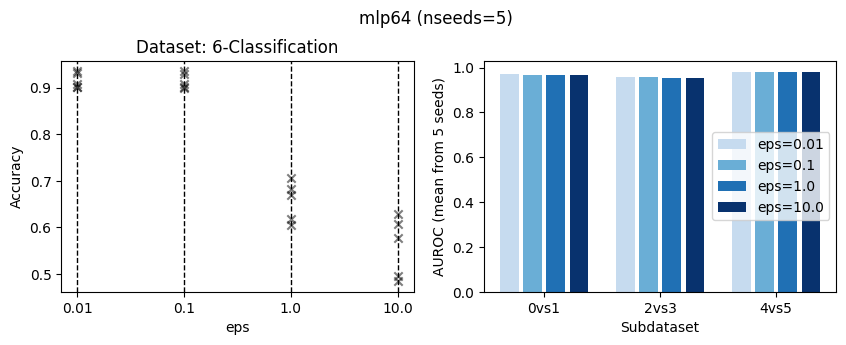

In [71]:
def viz_auccuracy_and_auroc_across_noise(
    model,
    seeds=[1, 2, 3, 4, 5],
    arr_eps=[0.01, 0.1, 1.0, 10.0]
):
    
    nseeds = len(seeds)
    ncols = 2
    
    
    colors = dict(
        zip(
            arr_eps,
            [0.25, 0.5, 0.75, 0.99]
        )
    )
    
    plt.figure(figsize=(ncols * 5, 3))
    plt.suptitle(f"{model} (nseeds={nseeds})" , y=1.05)
    plt.subplot(1, 2, 1)
    plt.title("Dataset: 6-Classification")
    for eix, eps in enumerate(arr_eps):
        
        arr_stats = []
        for seed in seeds:
            acc = load_meta(model, seed, eps)["accuracy"]
            arr_stats.append(acc)

        plt.scatter(
            [eix] * nseeds, 
            arr_stats,
            marker="x",
            color="k",
            alpha=0.5
        )
        plt.axvline(eix, ls="--", lw=1, color="k")
    plt.xticks(range(len(arr_eps)), arr_eps)
    plt.xlabel("eps")
    plt.ylabel("Accuracy")
    
    plt.subplot(1, 2, 2)
    
    steps = np.array([0, 5, 10])
    
    for eix, eps in enumerate(arr_eps):
        data = []
        
        for seed in seeds:
            aurocs = load_meta(model, seed, eps)["aurocs"]
            data.append((aurocs['0vs1'], aurocs['2vs3'], aurocs['4vs5']))
        
        data = np.array(data).mean(axis=0)

        plt.bar(steps + eix, data, color=cm.Blues(colors[eps]), label=f"eps={eps}")
        
    plt.legend(loc="right")
    plt.xticks(steps + 1.5, ["0vs1", "2vs3", "4vs5"])
    plt.ylabel(f"AUROC (mean from {nseeds} seeds)")
    plt.xlabel("Subdataset")
    
    
viz_auccuracy_and_auroc_across_noise("mlp64")

# AUROC for Compression

In [94]:
def load_auroc(eps, seeds, subset_slug, basis_name, model, layer):
    
    merged_key = "auroc"
    
    
    merged_stat = dict()
    
    arr_aurocs = []
    arr_area_aurocs = []
    arr_teacher_aurocs = []
    
    for six, seed in enumerate(seeds):
        
        file = DATA_DIR / f"toy-dataset-eps{eps}-seed{seed}" / model / f"subdataset--{subset_slug}" / layer / basis_name / "auroc.json"


        with open(file, "r") as fh:
            _stat = json.load(fh)
                        
        ks = np.array(_stat["ks"])
        if six == 0:
            merged_stat["ks"] = ks
        else:
            assert (merged_stat["ks"] == ks).all()
        
        auroc = np.array(_stat["auroc"])
        auroc = np.where(auroc < 0.5, 1-auroc, auroc)
        
        
        assert ks[0] == 0
        
        # ks = [0, 1, ..., d]
        # auroc: shape = (num ks,)
        area_auroc_varying_k = np.trapz(
            auroc,
            dx=1/ks[-1]
        )
        
        
        arr_aurocs.append(auroc)
        arr_area_aurocs.append(area_auroc_varying_k)
        arr_teacher_aurocs.append(auroc[-1])
        
    # shape: (num_seeds, len(ks))
    arr_aurocs = np.vstack(arr_aurocs)
    
    nseeds = len(seeds)
    assert arr_aurocs.shape[0] ==  nseeds
    
    merged_stat["mean_auroc"] = np.mean(arr_aurocs, axis=0)
    merged_stat["stderr_auroc"] = np.std(arr_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat["mean_area_auroc"] = np.mean(arr_area_aurocs, axis=0)
    merged_stat["stderr_area_auroc"] = np.std(arr_area_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat['mean_teacher_auroc'] = np.mean(arr_teacher_aurocs)
    merged_stat['std_teacher_auroc'] = np.std(arr_teacher_aurocs) / (nseeds ** 0.5)

    return merged_stat

    
load_auroc(eps=1.0, seeds=range(1, 1+1), subset_slug="2vs3", model="mlp64", basis_name="pca--centered", layer="act2")

{'ks': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 'mean_auroc': array([0.5       , 0.53086123, 0.5647046 , 0.95382137, 0.95452601,
        0.95907257, 0.95911451, 0.95908935, 0.95932842, 0.95963879,
        0.95972268, 0.95973107, 0.95969332, 0.95968073, 0.95962201,
        0.9596304 , 0.95966396, 0.95977301, 0.95975203, 0.95972687,
        0.95975623, 0.95976042, 0.95975623, 0.95974784, 0.95976042,
        0.95976462, 0.95978559, 0.95978559, 0.95978559, 0.95978559,
        0.95978559, 0.95978559]),
 'stderr_auroc': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'mean_area_auroc': 0.925307078587432,
 'stderr_area_auroc': 0.0,
 'mean_teacher_auroc': 0.9597855880856514,
 'std_teacher_auroc': 0.0}

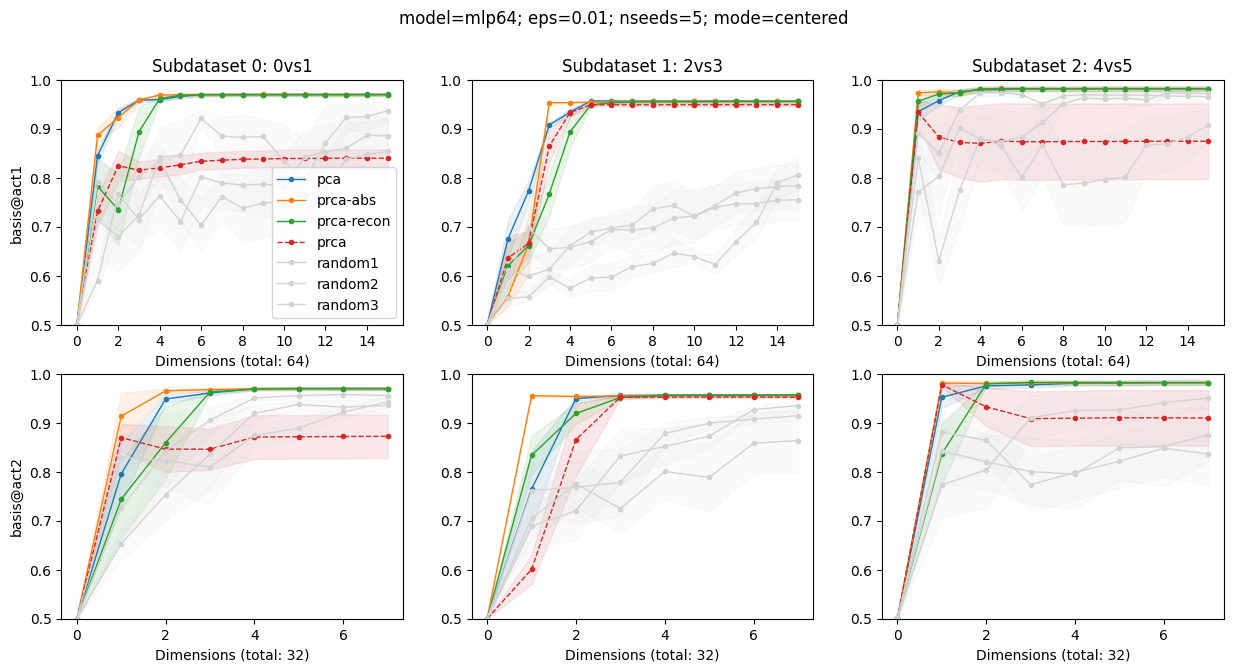

In [150]:
def color(name):
    if "random" in name:
        return "lightgray"
    elif "prca-reconreg" in name:
        beta = name.split("reg")[-1]
        color_norm = dict(zip(
            ["0.0", "0.1", "1.0", "10.0"][1:],
            [0.3, 0.5, 0.75, 0.8][:3]
        ))
        return cm.Greys(color_norm[beta])
    else:
        return None
def ls(name):
    if "prca" == name:
        return "--"
    else:
        return None
    
def viz_auroc(
    model="mlp64", eps=1.0, 
    seeds=[1, 2], 
    layers=["act1", "act2"],
    basis_names = [
        "pca", "prca-abs", "prca-recon",
        "prca",
        "random1", "random2", "random3",
    ],
    mode="centered"
):
    
    
    nrows = len(layers)
    ncols = 3
    plt.figure(figsize=(ncols*5, nrows*3.5))
    plt.suptitle(f"model={model}; eps={eps}; nseeds={len(seeds)}; mode={mode}")
    
    for lix, layer in enumerate(layers):
        
        
        for pix, slug in enumerate([
            "0vs1",
            "2vs3",
            "4vs5"
        ]):
            plt.subplot(nrows, ncols, lix*ncols + pix + 1)
            
            for basis in basis_names:
                basis_name = f"{basis}--{mode}"
                
                stats = load_auroc(eps=eps, seeds=seeds, subset_slug=slug, model=model, layer=layer, basis_name=basis_name)
                
                dims = len(stats['ks'])
                top_k = dims // 4
                ks = stats['ks'][:top_k]
                mean = stats['mean_auroc'][:top_k]
                std = stats['stderr_auroc'][:top_k] 
                plt.plot(
                    ks, mean, 
                    label=basis, 
                    lw=1,
                    color=color(basis),
                    ls=ls(basis),
                    marker="."
                )
                
                plt.fill_between(
                    ks,
                    mean - std,
                    mean + std, 
                    alpha=0.1,
                    color=plt.gca().lines[-1].get_color()
                )
                
            plt.xlabel(f"Dimensions (total: {dims})")
            plt.xticks(ks[::2])
            plt.ylim([0.5, 1])
            if pix == 0:
                plt.ylabel(f"basis@{layer}")

            if lix == 0:
                plt.title(f"Subdataset {pix}: {slug}")
                
            if lix == 0 and pix == 0:
                plt.legend()
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=0.01)

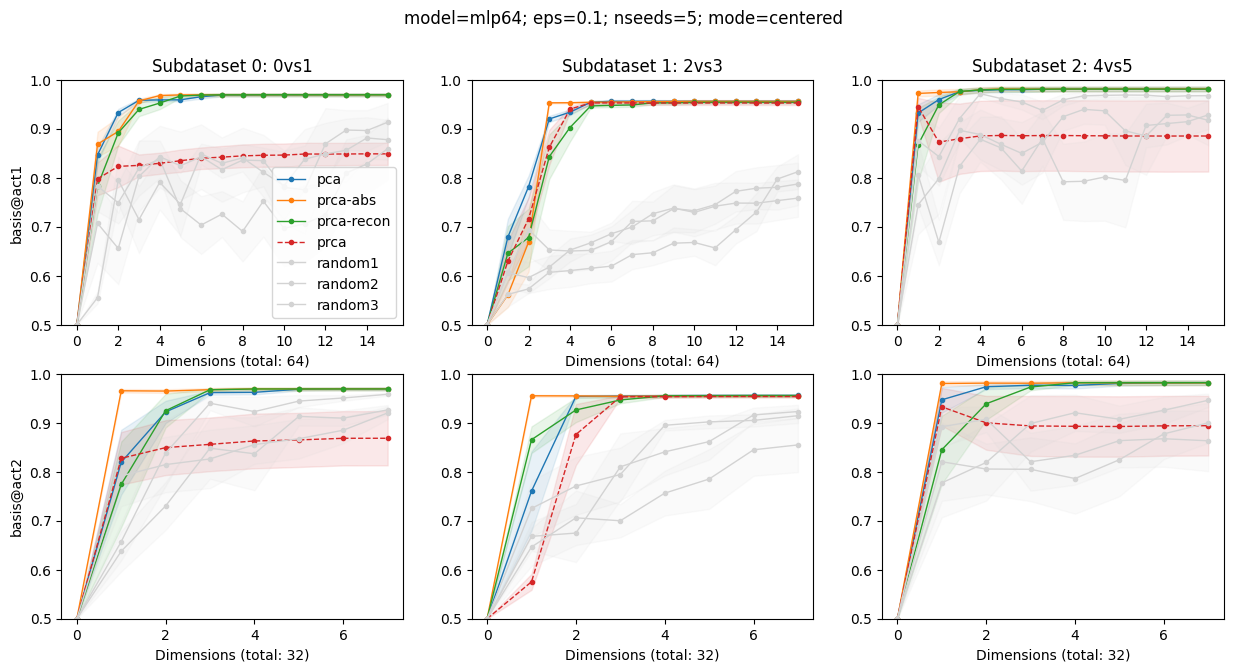

In [151]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=0.1)

In [152]:
# viz_auroc(seeds=[1, 2, 3, 4, 5], eps=0.1, mode="uncentered")

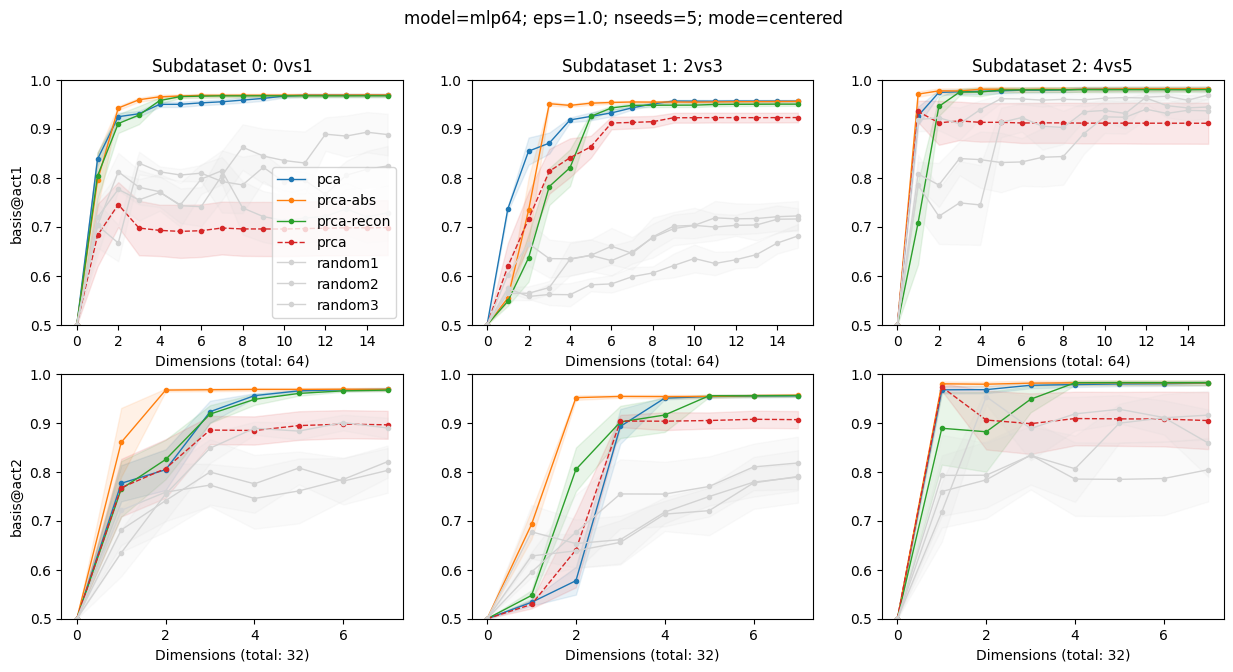

In [153]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=1.0)

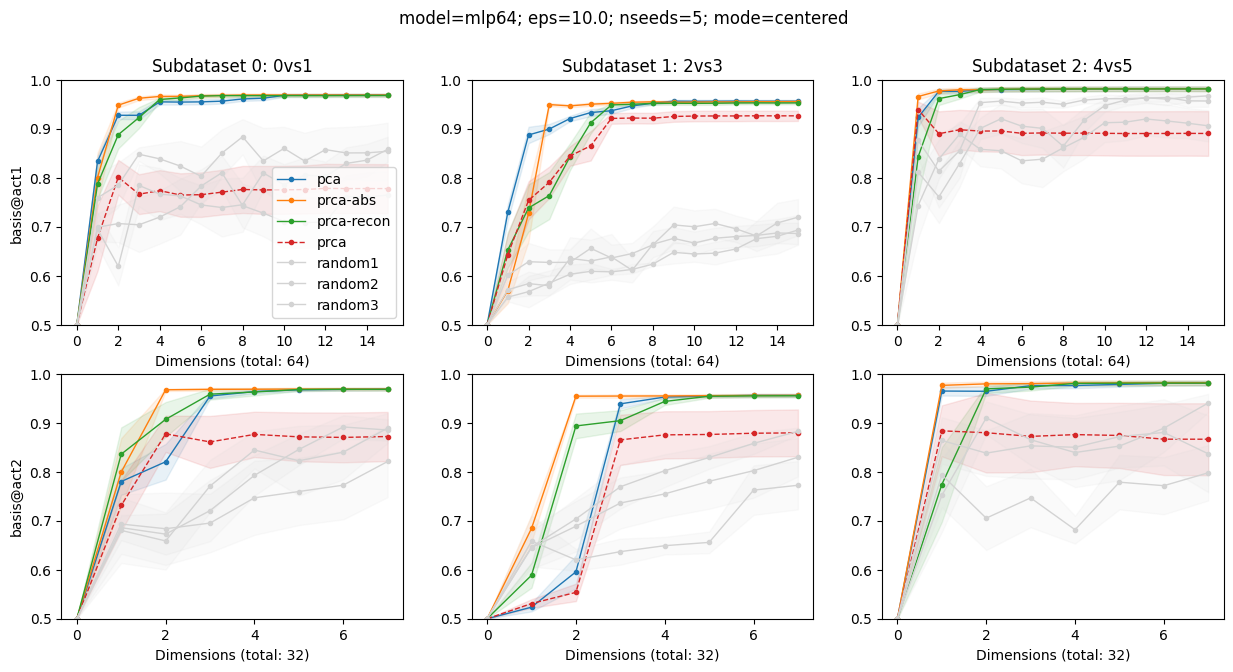

In [154]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=10.0)

# AUROC as EPS Increase

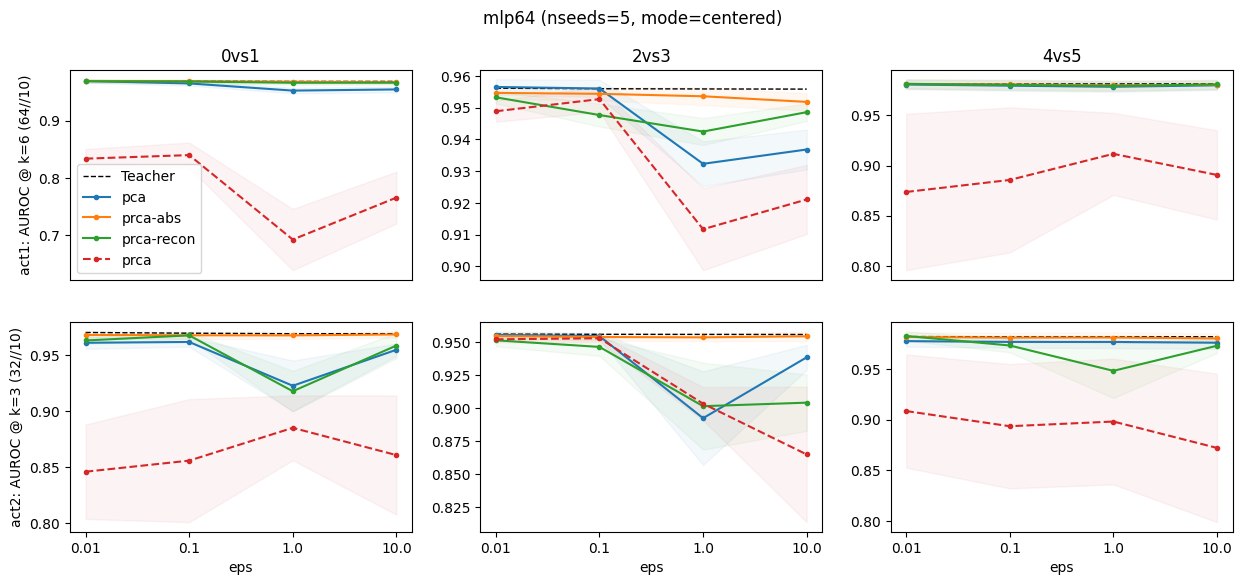

In [161]:
def auroc_as_eps_increase(
    model,
    arr_eps=[0.01, 0.1, 1.0, 10.0],
    arr_seeds=[1, 2, 3, 4, 5],
    mode="centered",
    arr_basis = [
        "pca",
        "prca-abs",
        "prca-recon",
        "prca",
    ]
):
    
    ratio = 10
  
    arr_layers = ["act1", "act2"]

    
    ncols = 3
    nrows = 2
    plt.figure(figsize=(5*ncols, 3*nrows))
    plt.suptitle(f"{model} (nseeds={len(arr_seeds)}, mode={mode})")
    
    xticks = np.arange(len(arr_eps))
    
    for dix, dataset in enumerate([
        "0vs1",
        "2vs3",
        "4vs5"
    ]):
  
    
        for lix, layer in enumerate(arr_layers):
            plt.subplot(nrows, ncols, lix * ncols + dix + 1)

            
            auroc_teachers = []
            
            
            for eps in arr_eps:
                _stat = []
                for seed in arr_seeds:
                    _stat.append(
                        load_meta(model, eps=eps, seed=seed)["aurocs"][dataset]
                    )
                
                auroc_teachers.append(_stat)

            plt.plot(
                xticks,
                np.mean(auroc_teachers, axis=1), 
                ls="--", color="k", lw=1,
                label="Teacher"
            )

            for basis in arr_basis:
                
                arr_mean = []
                arr_stderr  = []
                for eps in arr_eps:
                    stats = load_auroc(
                        eps=eps,
                        seeds=arr_seeds,
                        subset_slug=dataset, 
                        model=model,
                        basis_name=f"{basis}--{mode}",
                        layer=layer
                    )

                    d = stats['ks'][-1] + 1
                    k = d // ratio 

                    arr_mean.append(stats['mean_auroc'][k])
                    arr_stderr.append(stats['stderr_auroc'][k])

#                     plt.plot(
#                         stats['ks'][k],
#                         stats["mean_auroc"][:k]
#                     )
                
                arr_stderr = np.array(arr_stderr)
                arr_mean = np.array(arr_mean)
                plt.plot(
                    xticks, arr_mean, label=basis, 
                    marker=".",
                    color=color(basis),
                    ls=ls(basis)
                )
            
                plt.fill_between(
                    xticks,
                    arr_mean - arr_stderr,
                    arr_mean + arr_stderr, 
                    alpha=0.05,
                    color=plt.gca().lines[-1].get_color()
                )
                
            if lix == 0:
                plt.title(dataset)
                plt.xticks([])
            else:
                plt.xticks(xticks, arr_eps)
                plt.xlabel("eps")
            
            if dix == 0:
                plt.ylabel(f"{layer}: AUROC @ k={k} ({d}//{ratio})")
                
            if dix == 0 and lix == 0:
                plt.legend()
                



auroc_as_eps_increase("mlp64")

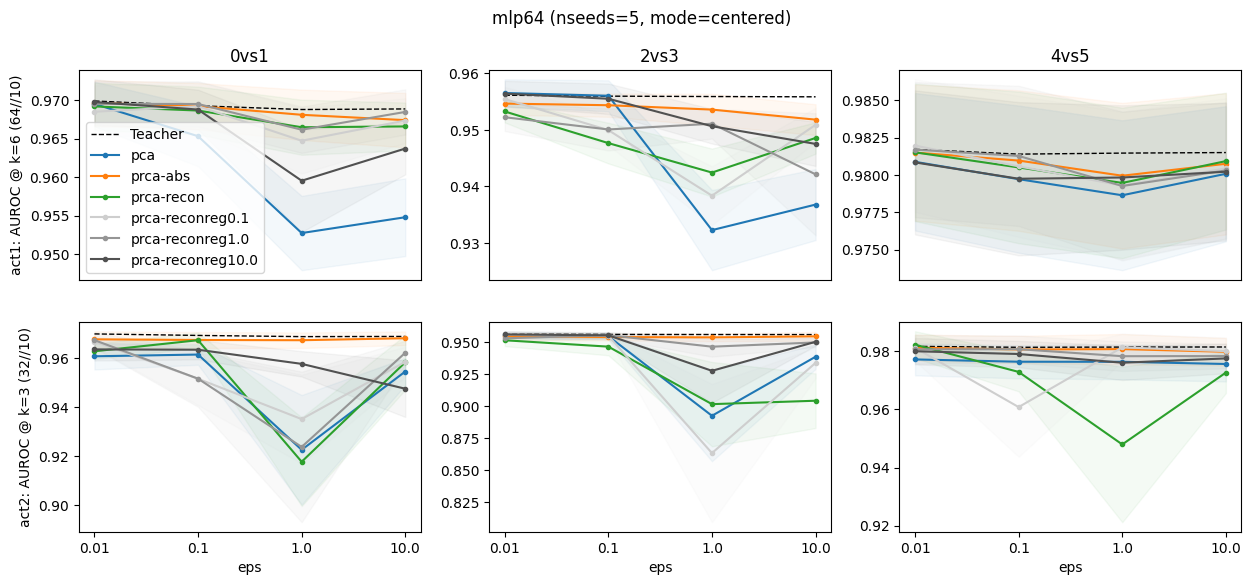

In [166]:
auroc_as_eps_increase(
    "mlp64",
    arr_basis=[
        "pca",
        "prca-abs",


        "prca-recon",
#         "prca-reconreg0.0",
        "prca-reconreg0.1",
        "prca-reconreg1.0",
        "prca-reconreg10.0",
#         "prca-abs",
    ]
)

In [163]:
raise

RuntimeError: No active exception to reraise

# Vis Table

In [11]:
# def table(model, eps, mode="centered"):
#     arr_layers = ["act1", "act2"]
#     arr_groups = ["0vs1", "2vs3", "4vs5"]
#     seeds = list(range(1, 5+1))
#     arr_bases = [
#         "random1", 
# #         "random2", "random3",
#         "pca", 
#         "prca-abs", "prca-recon", "prca",
#     ]
    
    
#     arr_rows = []
    
#     print(f"                 model={model}; eps={eps}; mode={mode}")
    
#     for lix, layer in enumerate(arr_layers):
        
#         for basis in arr_bases:
            
#             row = dict(layer=layer, basis=basis)
        
        
#             for slug in arr_groups:
#                 data = load_auroc(
#                     eps=eps,
#                     seeds=seeds,
#                     subset_slug=slug,
#                     model=model,
#                     layer=layer,
#                     basis_name=f"{basis}--{mode}"
#                 )
                
                
                
#                 row[slug] = "%.4f±%.4f" % (data["mean_area_auroc"], data["stderr_area_auroc"])
        
#             arr_rows.append(row)
        
    
#     return pd.DataFrame(arr_rows)

        
# table(model="mlp16", eps=0.01)

                 model=mlp16; eps=0.01; mode=centered


FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2023-05-s6/toy-experiments/toy-dataset-eps0.01-seed1/mlp16/subdataset--0vs1/act1/random1--centered/auroc.json'

In [ ]:
table(model="mlp64", eps=0.1, mode="centered")

In [ ]:
table(model="mlp64", eps=0.1, mode="uncentered")

# Accuracy and AUROC Analysis